# **Reinforcement Learning:** Multiarm Bandit

**ONE ARMED BANDIT** is a slang for a _slot machine_: It has one arm (one leaver) and it will rob you. Imagine, however, that there is not one but many such bandits. Some are worse than others, and some may even reward you. The problem, however, is that they all look the same, and we do not know how bad each one of them is. Since there are many, each with only one hand, the multitude of slot machines is referred to as **MULTIARM BANDIT**. 

<div class="alert alert-block alert-info">
<b>The Goal:</b> 
Devise a strategy for investigating the bandits (pulling the leavers and obtaining the reward/paying the penalty) so that the total gain is maximized (total loss is minimized).
</div>

## **Basic Imports**

In [30]:
from typing import Iterable
import random

import numpy as np
import matplotlib.pyplot as plt

In [31]:
%pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [32]:
from tqdm import trange

## **The Environment: Process Model**

### **Implement:** Simulating one Bandit

In [33]:
class Bandit:
    """A bandit with uniform reward distribution."""

    def __init__(self, mean: float, span: float):
        """Initialize the bandit.

        Regardless of the received action, the bandit will return reward
        uniformly sampled from segment [`mean`-`span`, `mean`+`span`].

        Args:
            mean (float): Mean (expected) value of the reward.
            span (float): Span of the reward.
        """
        # Save reward distribution parameters
        self.mean = mean
        self.span = span

    def pull_leaver(self) -> float:
        """Pull leaver and obtain reward.

        Returns:
            float: The obtained reward.
        """
        # Generate random number in range [mean-span, mean+span]
        # random.random() - returns number between 0 and 1 
        # (random.random()-0.5) - returns number between -0.5 and 0.5
        # 2*span * (random.random()-0.5) - returns number between -span and +span
        return self.mean + 2*self.span * (random.random()-0.5)

### **Testing one Bandit**

We should always test a piece of code :) This is not a formal test, but it is still a test.

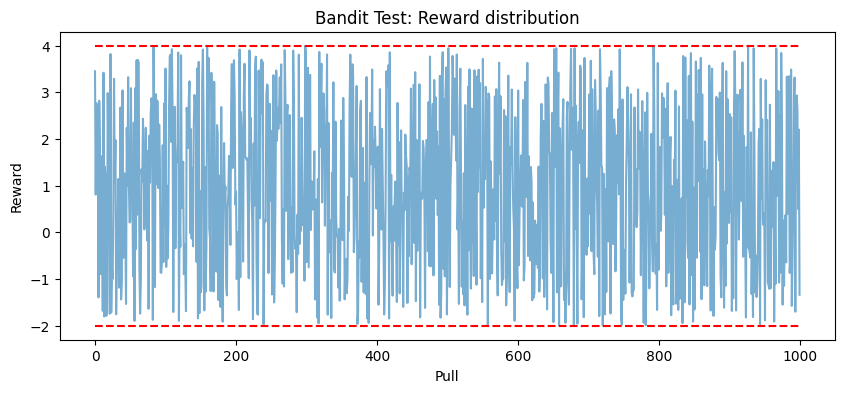

In [34]:
# Define parameters for test
test_mean = 1.0
test_span = 3.0
test_epochs = 1000

# Create test Bandit
test_bandit = Bandit(test_mean, test_span)

# Testing by pulling leaver 'test_epochs' number of times (one pull -> one epoch)
test_rewards = [test_bandit.pull_leaver() for _ in range(test_epochs)]

# Plot results
plt.figure(figsize=(10,4))
plt.plot(test_rewards, label="rewards", alpha=0.6)
plt.plot((test_mean + test_span) * np.ones(test_epochs), linestyle="--", color="r")
plt.plot((test_mean - test_span) * np.ones(test_epochs), linestyle="--", color="r")
plt.title("Bandit Test: Reward distribution")
plt.xlabel("Pull")
plt.ylabel("Reward")
plt.show()

### **Implement:** Environment of Bandits

Now, we define an environment consisting of several bandits.

In [35]:
class BanditsEnvironment:
    """An environment consisting of multiple bandits."""

    def __init__(self, bandits: Iterable[Bandit], penalty=1000):
        """Initialize the environment.

        Args:
            bandits (iter[Bandit]): Bandits to be used within the environment.
            penalty (int, optional): 
                If the external agents attempts to use a bandit not in the list,
                i.e. if the chosen action is negative or bigger than the index of
                the last bandit, the returned reward will be `-penalty`. Defaults to 1000.
        """
        self.bandits: list[Bandit] = list(bandits)
        self.penalty = penalty

    def take_action(self, action: int):
        """
        Select bandit `action` and pull its leaver. 
        
        If the selected agent is valid, return the obtained reward.
        Otherwise, return negative penalty.
        """
        # Validate action 
        if action < 0 or action >= len(self.bandits):
            return -self.penalty                        # If invalid give penalty
        else:
            return self.bandits[action].pull_leaver()   # Pull leaver (make action) on Bandit[action]

<div class="alert alert-block alert-info">
<b>Tip:</b> 
The <b>`Sequence`</b> and <b>`Iterable`</b> <b>abstract base classes</b> (can also be used as <b>type annotations</b>) usually adhere to the following conventions:

* <b>`Iterable`</b> is any object that defines <b>`__iter__`</b> or <b>`__getitem__`</b>.
* <b>`Sequence`</b> is any object that defines <b>`__getitem__`</b> and <b>`__len__`</b>. By definition, any sequence is an iterable. 

The <b>`Sequence`</b> class also defines other methods such as <b>`__contains__`</b>, <b>`__reversed__`</b> that calls the two required methods.

<b>`list`</b>, <b>`tuple`</b>, <b>`str`</b> are the most common sequences. Some built-in iterables are not sequences.
</div>

For more tips and tricks regarding notebook markdown, please see [here](https://towardsdatascience.com/modernize-your-sinful-python-code-with-beautiful-type-hints-4e72e98f6bf1).


### **Testing the Environment**

Let us now test the environment. We will build it so that the mean value of the reward returned by each bandit is equal to the square of its index. The span will be equal to the index.

In [36]:
# Define parameters for test
test_env_size = 5

# Create Environment with 5 Bandits that had (mean, span) -> (i², i)
test_bandits = [Bandit(i**2, i) for i in range(test_env_size)]
test_environment = BanditsEnvironment(test_bandits)

#### **Test:** Fixed action chosen

We will first test whether one of the bandits behaves as expected...

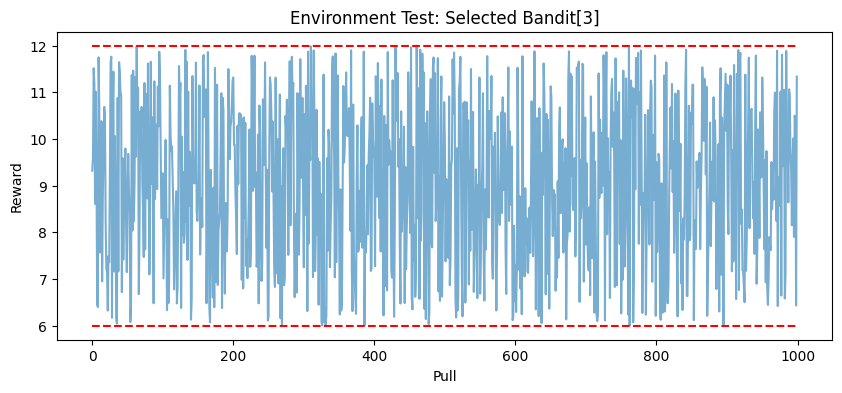

In [37]:
# Define parameters for test
selected_bandit = 3

# Get reward from testing selected Bandit by pulling leaver 'test_epochs' number of times
test_rewards = [test_environment.take_action(selected_bandit) for _ in range(test_epochs)]

# Plot results
plt.figure(figsize=(10,4))
plt.plot(test_rewards, label="rewards", alpha=0.6)
plt.plot((selected_bandit**2 + selected_bandit) * np.ones(test_epochs), linestyle="--", color="r")
plt.plot((selected_bandit**2 - selected_bandit) * np.ones(test_epochs), linestyle="--", color="r")
plt.title(f"Environment Test: Selected Bandit[{selected_bandit}]")
plt.xlabel("Pull")
plt.ylabel("Reward")
plt.show()

#### **Test:** Invalid action chosen

Then, we will test if the environment behaves correctly when an invalid action is given...

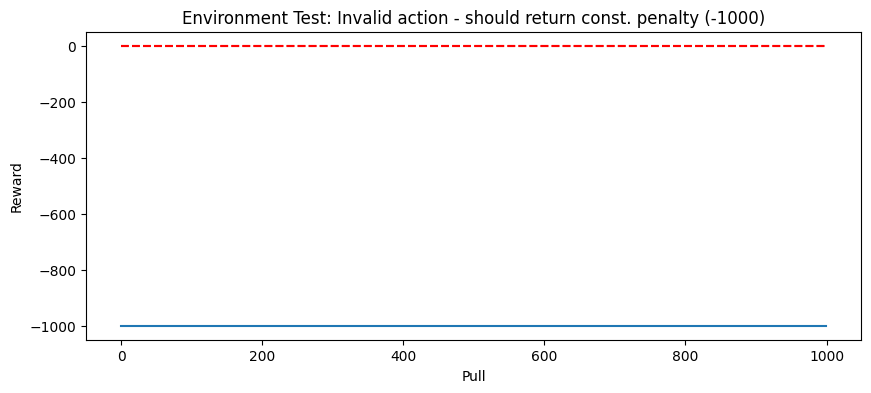

In [38]:
# Define parameters for test
selected_bandit = -1

# Get reward from testing selected Bandit
test_rewards = [test_environment.take_action(selected_bandit) for _ in range(test_epochs)]

# Plot results
plt.figure(figsize=(10,4))
plt.plot(test_rewards, label="rewards")
plt.plot((selected_bandit**2 + selected_bandit) * np.ones(test_epochs), linestyle="--", color="r")
plt.plot((selected_bandit**2 - selected_bandit) * np.ones(test_epochs), linestyle="--", color="r")
plt.title("Environment Test: Invalid action - should return const. penalty (-1000)")
plt.xlabel("Pull")
plt.ylabel("Reward")
plt.show()

#### **Test:** Random actions are chosen

Finally, let us check if the code runs with arbitrarily selected actions. This is quite tricky to do, since the whole system behaves stochastically. However, we know that the bandits are independent, and also that their mean values are 0, 1, 4, 9, and 16. Assuming each bandit is activated with the same probability, the mean value rewards obtained after many actions should be (0 + 1 + 4 + 9 + 16)/5 = 6.

In [39]:
# Get reward from testing random selected Bandit by pulling leaver 'test_epochs' number of times
test_rewards = [test_environment.take_action(random.randint(0, 4)) for _ in range(test_epochs)]

theoretical_mean = sum(i**2 for i in range(5)) / 5
print(f"Theoretical mean (random action): {theoretical_mean}")

# Calculate test mean value 
test_mean = sum(test_rewards) / test_epochs
print("Test mean (random action): ", test_mean)

Theoretical mean (random action): 6.0
Test mean (random action):  5.731788402192791


## **Implement:** Decision Policies

### **Implement:** Greedy decision policy

In [40]:
def choose_greedy_action(q):
    # np.argmax returns the index of the element with the largest value
    return np.argmax(q)

### **Test:** Greedy decision policy

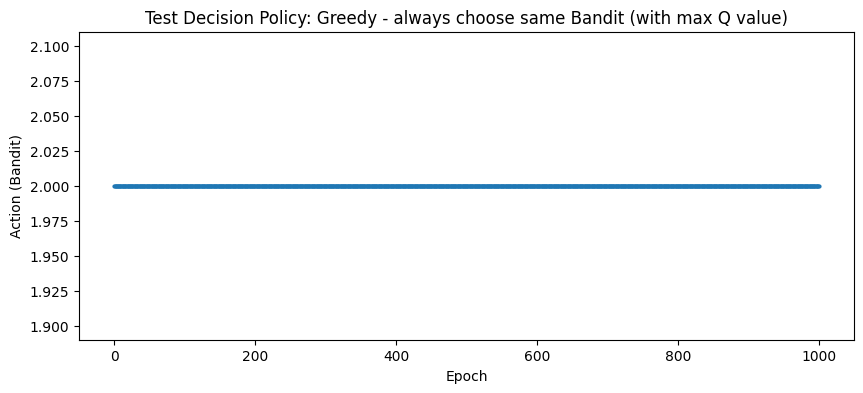

In [41]:
# Define fixed q values array
test_q_values = [1, 2, 3, 2, 1]

# We demonstrate that greedy always chooses the same bandit
test_actions = [choose_greedy_action(test_q_values) for _ in range(test_epochs)]

# Plot results
plt.figure(figsize=(10,4))
plt.plot(test_actions, 'o-', markersize=2)
plt.title("Test Decision Policy: Greedy - always choose same Bandit (with max Q value)")
plt.xlabel("Epoch")
plt.ylabel("Action (Bandit)")
plt.show()

### **Implement:** Random decision policy

In [42]:
def choose_random_action(n):
    # random.randint(0, n-1) returns a number between 0 and n-1 inclusive
    return random.randint(0, n-1)

### **Implement:** $\varepsilon$-greedy decision policy

In [43]:
def choose_eps_greedy_action(q, eps):
    # random.random() returns a number between 0 and 1
    if random.random() > eps:
        # With probability (1-eps) we choose greedy
        return choose_greedy_action(q)
    else:
        # With probability eps we choose randomly (exploration)
        return choose_random_action(len(q))

### **Test:**  $\varepsilon$-greedy decision policy with different $\varepsilon$

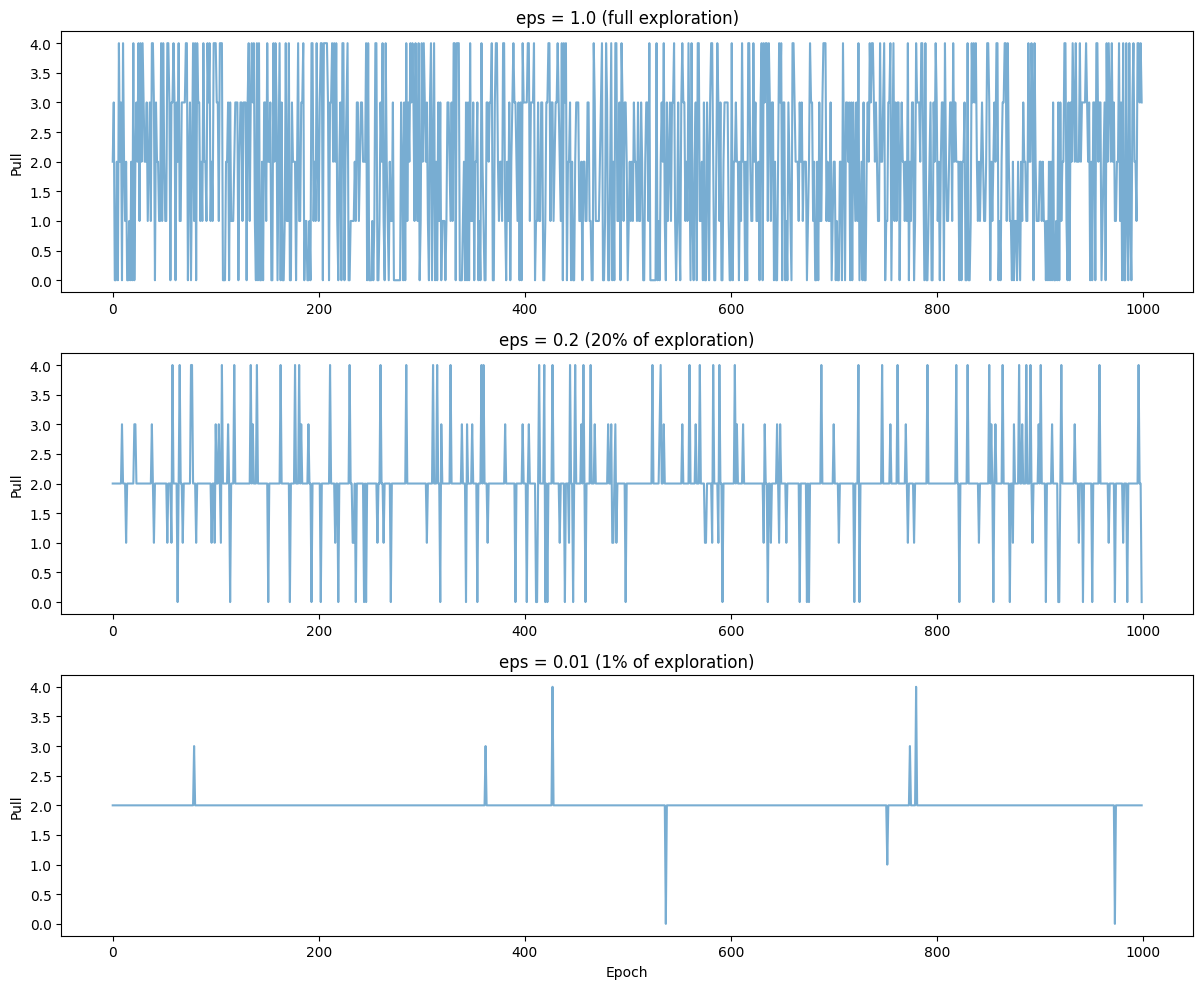

In [44]:
plt.figure(figsize=(12,10))

# eps = 1.0 (full exploration)
plt.subplot(3, 1, 1)
policy_actions_eps_1 = [choose_eps_greedy_action(test_q_values, 1.0) for _ in range(test_epochs)]
plt.plot(policy_actions_eps_1, alpha=0.6)
plt.title("eps = 1.0 (full exploration)")
plt.ylabel("Pull")

# eps = 0.2 (20% of exploration)
plt.subplot(3, 1, 2)
policy_actions_eps_2 = [choose_eps_greedy_action(test_q_values, 0.2) for _ in range(test_epochs)]
plt.plot(policy_actions_eps_2, alpha=0.6)
plt.title("eps = 0.2 (20% of exploration)")
plt.ylabel("Pull")

# eps = 0.01 (1% of exploration)
plt.subplot(3, 1, 3)
policy_actions_eps_3 = [choose_eps_greedy_action(test_q_values, 0.01) for _ in range(test_epochs)]
plt.plot(policy_actions_eps_3, alpha=0.6)
plt.title("eps = 0.01 (1% of exploration)")
plt.ylabel("Pull")

plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

## **Implement:** Training Loop

In [53]:
# Define parameters for training
BANDITS_NO = 5          # Number of Bandits in environment
ATTEMPTS_NO = 5000      # Number of epochs
ALPHA = 0.1             # Learning rate
EPSILON = 0.1           # Epsilon for eps-greedy policy

# Create Bandits with (mean, span) -> (random [-5, 5], span [0, 5])
bandits = [Bandit(10*(random.random()-0.5), 5*random.random()) for _ in range(BANDITS_NO)]

# Create environment for Bandits
environment = BanditsEnvironment(bandits)

# Initialization of Q values (optimistic initialization - we start with high values)
q_values = [100 for _ in range(BANDITS_NO)]
rewards = []

# Main learning algorithm
for t in trange(ATTEMPTS_NO):
    # Choose an action using eps-greedy policy
    action = choose_eps_greedy_action(q_values, EPSILON)
    
    # Perform an action and receive a reward
    reward = environment.take_action(action)

    # Update Q-value using the Q-learning update rule:
    q_values[action] = q_values[action] + ALPHA * (reward - q_values[action])
    
    # Save the reward for analysis
    rewards.append(reward)

100%|██████████| 5000/5000 [00:00<00:00, 289258.36it/s]


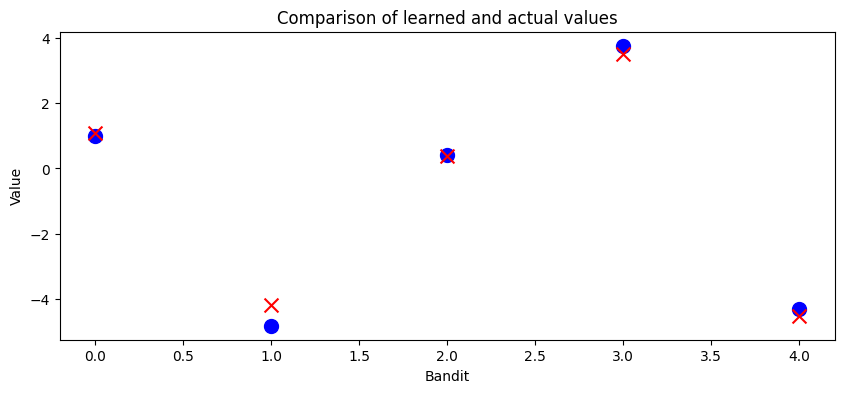

In [ ]:
plt.figure(figsize=(10,4))
plt.scatter(range(len(q_values)), q_values, marker="o", s=100, color='blue')
plt.scatter(range(len(q_values)), [b.mean for b in environment.bandits], marker="x", s=100, color='red')
plt.title("Comparison of learned and actual values")
plt.xlabel("Bandit")
plt.ylabel("Value")
plt.show()

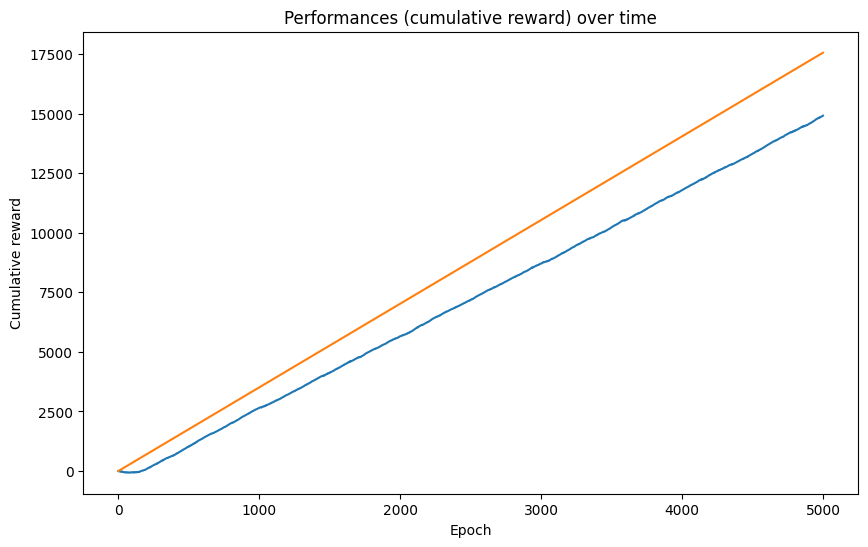

In [58]:
# Cumulative sum of rewards over time
gain = np.cumsum(rewards)

# Get maximal reward mean of Bandit (that is the best Bandit) 
max_reward_mean = max([bandit.mean for bandit in environment.bandits])

# Get ideal cumulative sum of rewards
optimal_gain = np.cumsum(max_reward_mean * np.ones(len(rewards)))

# Plot results
plt.figure(figsize=(10,6))
plt.plot(gain)
plt.plot(optimal_gain)
plt.title("Performances (cumulative reward) over time")
plt.xlabel("Epoch")
plt.ylabel("Cumulative reward")
plt.show()

## **Assignments for Individual Work**

- **Task 1:** Experiment with the value of `epsilon`. Try smaller values, and verify that the slope difference is smaller. Verify also the oposite fact: increasing `epsilon` decreases the slope of the plotted achieved gain. Explain.   

- **Task 2:** Perform a training run to learn the `q` vector (in essence, to estimate the mean value of the reward returned by each bandit). Create a test loop, in which the learned `q` values remain fixed. Compare performance of the agent to the ideal performance (as it is done in the previous point).

- **Task 3:** Plot the change of the estimated `q` values in time. Show that with passing time the algorithm sucessfully approximates mean rewards of all bandits.

- **Task 4:** Modify the environment so that the mean values of all bandits change in time. Repeat the training procedure. Evaluate its effectiveness.

## **Solution**

### **Task 1**

Experiment with the value of `epsilon`. Try smaller values, and verify that the slope difference is smaller. Verify also the oposite fact: increasing `epsilon` decreases the slope of the plotted achieved gain. Explain.   

In [ ]:
# Define constants for task
BANDITS_NUM = 5
EPOCH_NUM = 5000
ALPHA = 0.1

# List of epsilon values to test for epsilon-greedy strategy
epsilon_values = [0.01, 0.05, 0.1, 0.2, 0.5]

# Dictionary to store results for each epsilon value
results = {}

In [ ]:
# Initialize Bandits with: means (random between -5 and 5), std. deviations (random between 0 and 5)
bandits = [Bandit(10 * (np.random.random() - 0.5), 5 * np.random.random()) for _ in range(BANDITS_NUM)]

# Test each epsilon value
for epsilon in epsilon_values:
    # Create a new environment with the bandits
    environment = BanditsEnvironment(bandits)

    # Initialize Q-values optimistically (high initial value encourages exploration)
    q_values = [100 for _ in range(len(bandits))]

    # List to store rewards obtained at each epoch
    rewards = []

    # Run the experiment for the specified number of epochs
    for epoch in range(EPOCH_NUM):
        # Choose an action using epsilon-greedy strategy
        action = choose_eps_greedy_action(q_values, epsilon)

        # Get reward from the chosen bandit
        reward = environment.take_action(action)

        # Update Q-value for the chosen action using the reward
        q_values[action] = q_values[action] + ALPHA * (reward - q_values[action])

        # Store the obtained reward
        rewards.append(reward)

    # Save results for this epsilon value
    results[epsilon] = { "final_q_values": q_values,        # Final Q-values after all epochs
                        "rewards": rewards}                 # Reward history


In [ ]:
# Calculate the maximum possible mean reward (optimal strategy)
max_reward_mean = max([bandit.mean for bandit in environment.bandits]) 

# Calculate what the cumulative reward would be if we always chose the best bandit
optimal_gain = np.cumsum(max_reward_mean * np.ones(EPOCH_NUM))

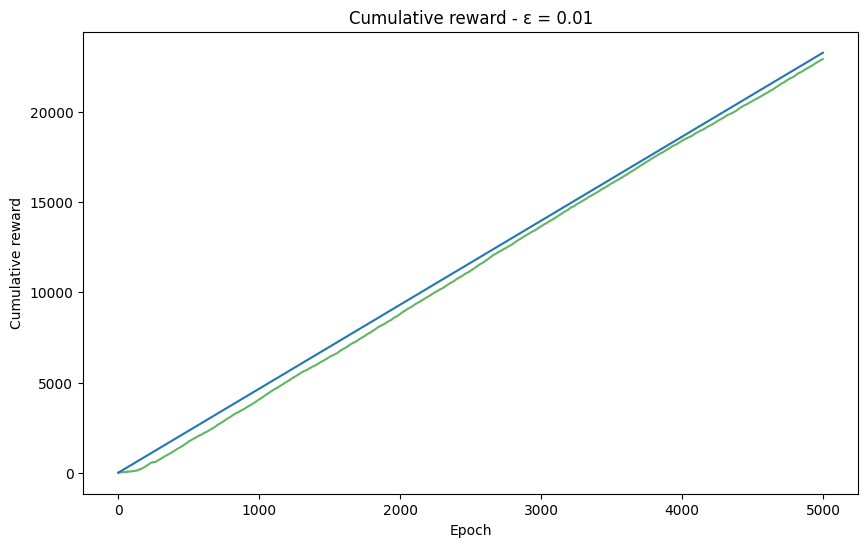

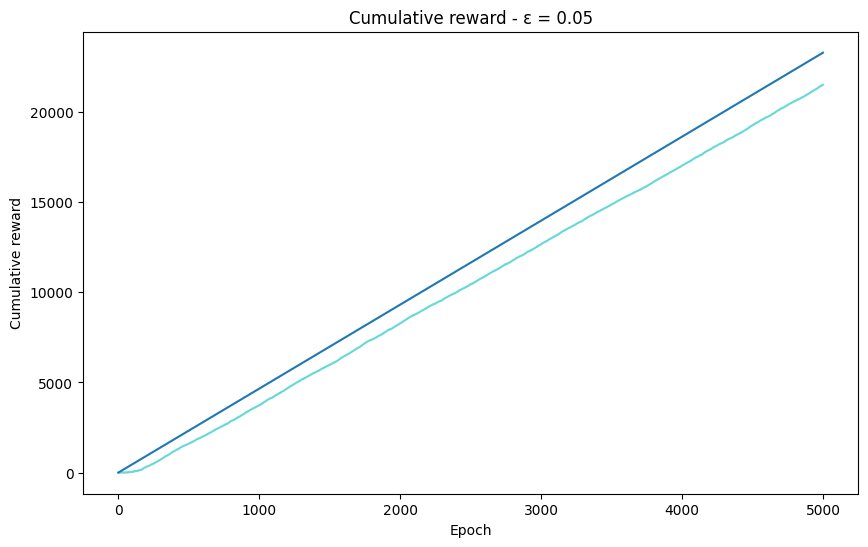

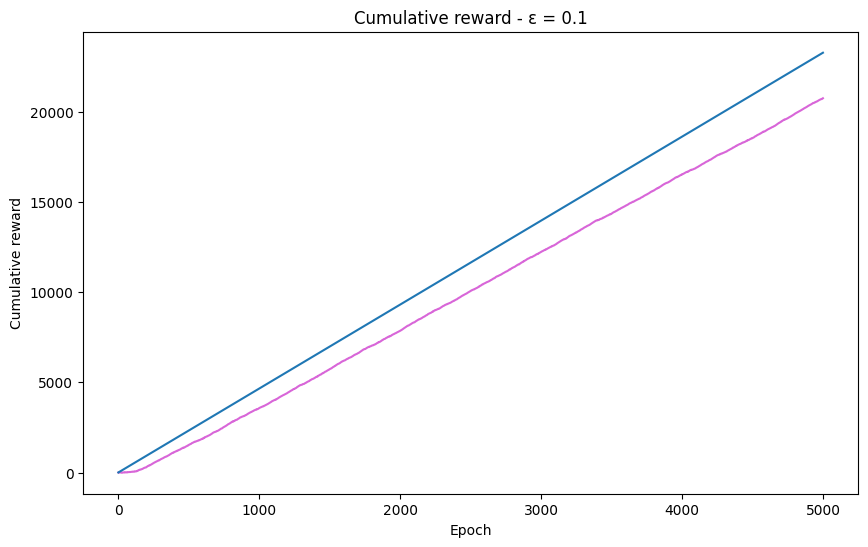

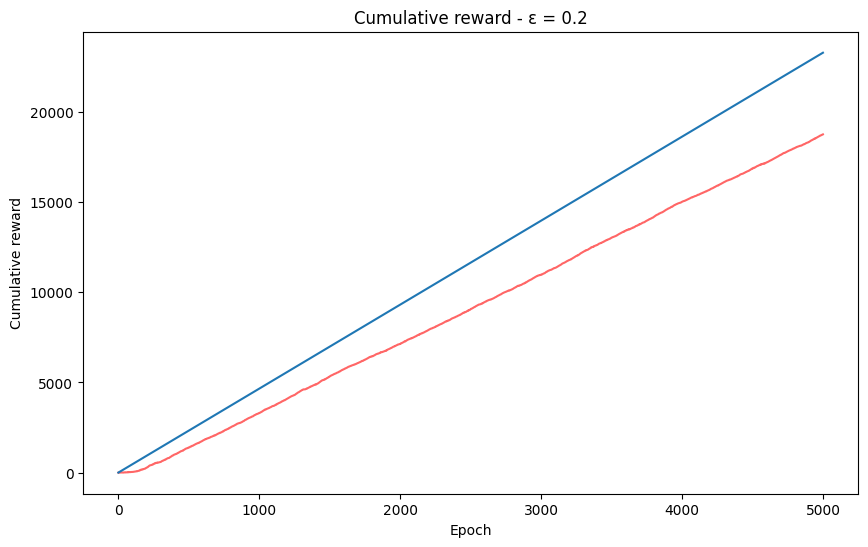

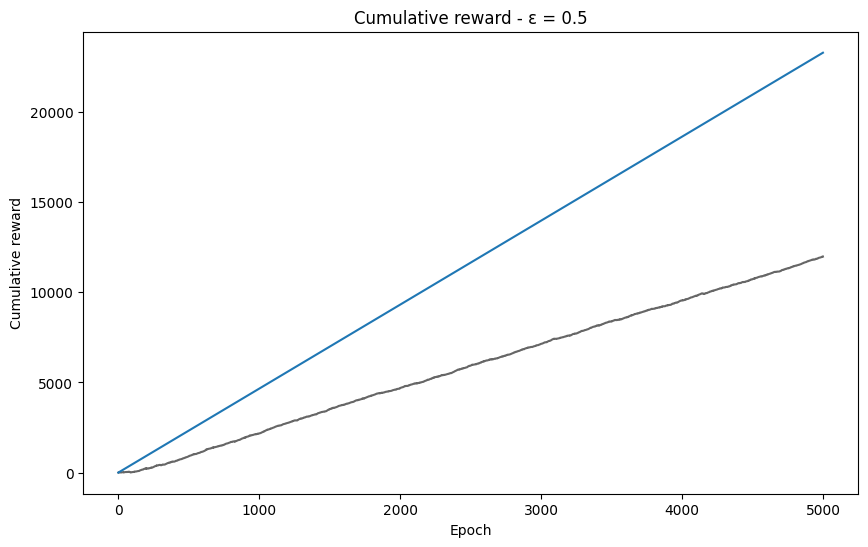

In [ ]:
colors=['g', 'c', 'm', 'r', 'k']

# Plot results for each epsilon value
for epsilon, color in zip(epsilon_values, colors):
    plt.figure(figsize=(10,6))
    plt.plot(np.cumsum(results[epsilon]['rewards']), alpha=0.6, color=color)
    plt.plot(optimal_gain)
    plt.title(f"Cumulative reward: ε = {epsilon}")
    plt.xlabel("Epoch")
    plt.ylabel("Cumulative reward")
    plt.show()

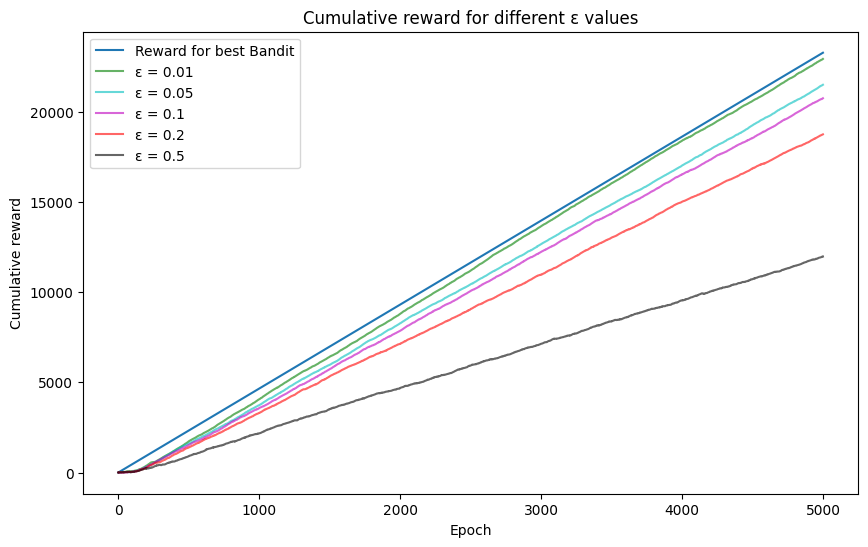

In [ ]:
# Plot results for different epsilon values for comparison 
plt.figure(figsize=(10,6))

plt.plot(optimal_gain, label="Reward for best Bandit")

for epsilon, color in zip(epsilon_values, colors):
    plt.plot(np.cumsum(results[epsilon]['rewards']), label=f"ε = {epsilon}", alpha=0.6, color=color)

plt.title(f"Cumulative reward for different ε values")
plt.xlabel("Epoch")
plt.ylabel("Cumulative reward")
plt.legend()
plt.show()

### **Task 2**

Perform a training run to learn the `q` vector (in essence, to estimate the mean value of the reward returned by each bandit). Create a test loop, in which the learned `q` values remain fixed. Compare performance of the agent to the ideal performance (as it is done in the previous point).

In [131]:
BANDITS_NUM = 5
TRAINING_EPOCH_NUM = 3000
TEST_EPOCH_NUM = 2000
ALPHA = 0.1
EPSILON = 0.1

# Initialization of Q values (optimistically)
q_values_training = [100 for _ in range(BANDITS_NUM)]

bandits = [Bandit(10 * (random.random() - 0.5), 5 * random.random()) for _ in range(BANDITS_NUM)]

environment = BanditsEnvironment(bandits)

In [132]:
def training_loop_q_val(q_values_training, epsilon, alpha, epoch_num):

    # Initialized list to store training rewards 
    training_rewards = []

    # Run training
    for epoch in range(epoch_num):

        # Choose action and get reward for it
        action = choose_eps_greedy_action(q_values_training, epsilon)
        reward = environment.take_action(action)

        # Update Q-value for chosen action
        q_values_training[action] += alpha * (reward - q_values_training[action])

        # Save reward
        training_rewards.append(reward)

    # Return learned Q-values and rewards Bandits gained
    return q_values_training, training_rewards


In [133]:
def test_loop_q_val(q_values_test, epoch_num):
    
    # Initialized list to store test rewards
    test_rewards = []

    # Run test
    for epoch in range(epoch_num):
        
        # Choose action greedy and get reward  -> the Bandit with highest learned Q-value
        action = choose_greedy_action(q_values_test)
        reward = environment.take_action(action)

        # Save reward
        test_rewards.append(reward)

    # Return learned Q-values (although fixed but just for consistency) and rewards Bandits gained 
    return q_values_test, test_rewards

In [134]:
# Save learned Q-values and obtained rewards from performed training 
training_q_values, training_rewards = training_loop_q_val(q_values_training, epsilon=EPSILON, alpha=ALPHA, epoch_num=TRAINING_EPOCH_NUM)

# Get maximal reward mean of Bandit learning while training (that is the best Bandit) 
max_reward_mean = max(bandit.mean for bandit in environment.bandits)

# Get cumulative reward for always choosing best Bandit
traning_optimal_gain = np.cumsum([max_reward_mean] * TRAINING_EPOCH_NUM)

# Get cumulative reward gained while training
traning_gain = np.cumsum(training_rewards)

# Print and plot results
for i, q_value in enumerate(training_q_values):
    print(f"Bandit[{i}]: Q = {q_value:.2f} | Mean = {bandits[i].mean:.2f} | Error = {abs(q_value - bandits[i].mean):.2f}")

Bandit[0]: Q = -0.49 | Mean = -0.27 | Error = 0.22
Bandit[1]: Q = 2.00 | Mean = 1.88 | Error = 0.13
Bandit[2]: Q = 3.39 | Mean = 3.24 | Error = 0.15
Bandit[3]: Q = -1.10 | Mean = -1.56 | Error = 0.46
Bandit[4]: Q = 2.25 | Mean = 2.39 | Error = 0.14


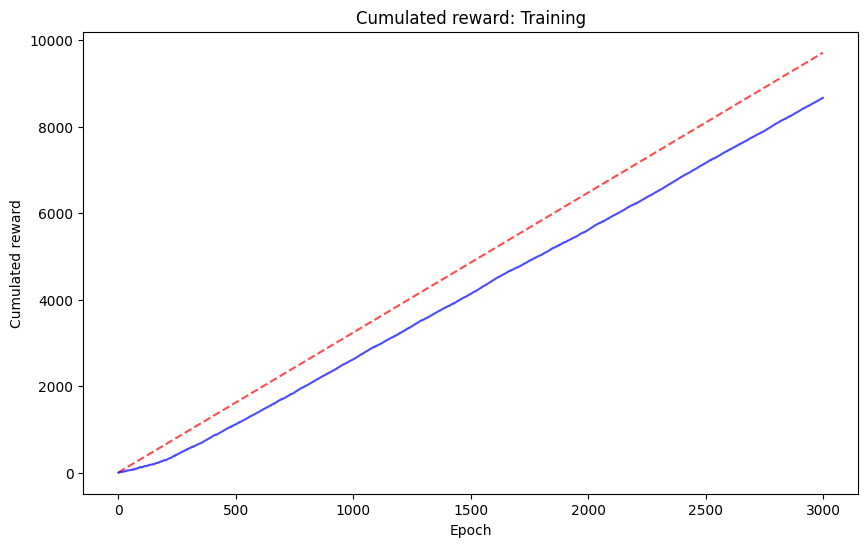

In [135]:
plt.figure(figsize=(10,6))
plt.plot(traning_optimal_gain, alpha=0.7, color='r', linestyle='--')
plt.plot(traning_gain, alpha=0.7, color='b')
plt.xlabel("Epoch")
plt.ylabel("Cumulated reward")
plt.title("Cumulated reward: Training")
plt.show()

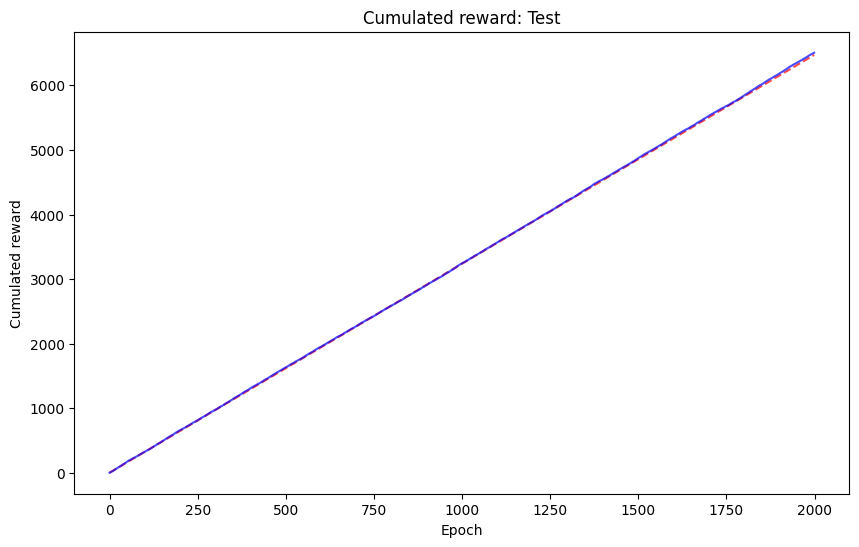

In [136]:
# Initialied test Q-values by fixing values gained from training
test_q_values = training_q_values.copy()

# Save Q-values (stayed same cuz fixed) and obtained rewards from performed test 
test_q_values, test_rewards = test_loop_q_val(test_q_values, epoch_num=TEST_EPOCH_NUM)

# Get cumulative reward for always choosing best Bandit
test_optimal_gain = np.cumsum([max_reward_mean] * TEST_EPOCH_NUM)

# Get cumulative reward gained while test
test_gain = np.cumsum(test_rewards)

# Plot results
plt.figure(figsize=(10,6))
plt.plot(test_optimal_gain, alpha=0.7, color='r', linestyle='--')
plt.plot(test_gain, alpha=0.7, color='b')
plt.xlabel("Epoch")
plt.ylabel("Cumulated reward")
plt.title("Cumulated reward: Test")
plt.show()

### **Task 3**

Plot the change of the estimated `q` values in time. Show that with passing time the algorithm sucessfully approximates mean rewards of all bandits.

In [ ]:
BANDITS_NUM = 5
EPOCH_NUM = 5000
EPSILON = 0.1
ALPHA = 0.1

# Initialized starting Q-values (optimistically, much bigger then real Q-values so we se progess)
q_values = [100 for _ in range(BANDITS_NUM)]

training_rewards = []

# Initialized matrix to save update of every Q-value in each epoch
q_value_estimations = np.zeros((EPOCH_NUM, BANDITS_NUM))

for epoch in range(TRAINING_EPOCH_NUM):

    action = choose_eps_greedy_action(q_values, EPSILON)
    
    reward = environment.take_action(action)

    q_values[action] = q_values[action] + ALPHA * (reward - q_values[action])

    training_rewards.append(reward)

    # Save updated Q-values
    q_value_estimations[epoch] = q_values.copy()


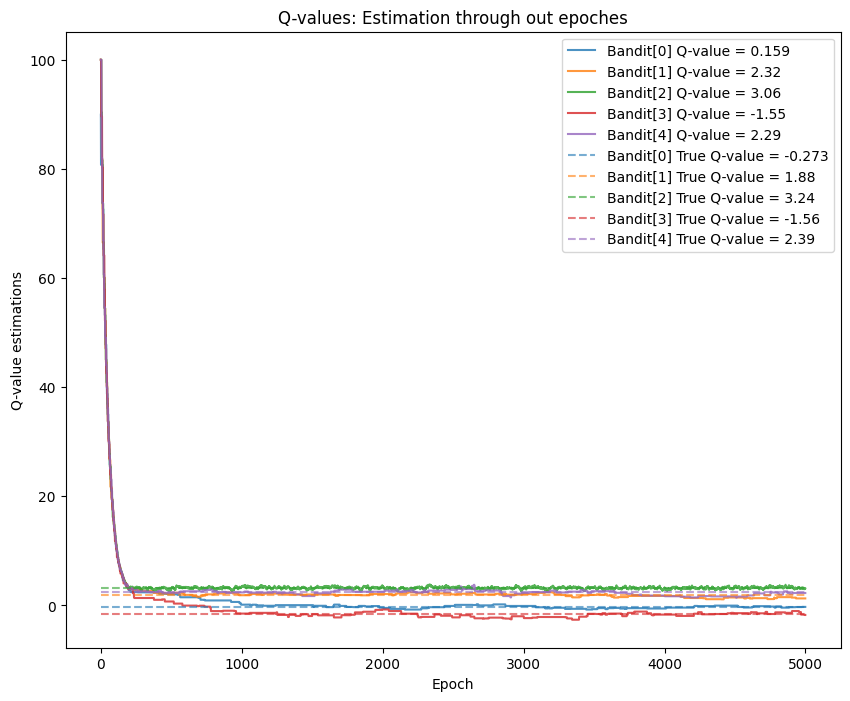

In [ ]:
# Saved true Q-values (means of each Bandit)
true_q_values = [bandit.mean for bandit in environment.bandits]

plt.figure(figsize=(10,8))

# Plot evolution of estimating Q-values for each Bandit
for bandit in range(BANDITS_NUM):
    plt.plot(q_value_estimations[:, bandit], alpha=0.8, label=f"Bandit[{bandit}] Q-value = {q_values[bandit]:.3}", color=f'C{bandit}')

# Plot true Q-values for each of Bandit
for bandit in range(BANDITS_NUM):
    plt.hlines(true_q_values[bandit], 0, TRAINING_EPOCH_NUM, alpha=0.6, label=f"Bandit[{bandit}] True Q-value = {true_q_values[bandit]:.3}", colors=f"C{bandit}", linestyle="--")

plt.title("Q-values: Estimation through out epoches")
plt.xlabel("Epoch")
plt.ylabel("Q-value estimations")
plt.legend()
plt.show()

In [212]:
# Print estimated Q-values, true Q-values and error in etimation
print("Bandit Q-values: 'Estimated' vs. 'True'")
for i, (q_value, true_q_value) in enumerate(zip(q_values, true_q_values)):
    print(f"Bandit[{i}]: Q = {q_value:.2} | True Q = {true_q_value:.2} | Error = {abs(q_value - true_q_value):.2} |")

Bandit Q-values: 'Estimated' vs. 'True'
Bandit[0]: Q = 0.16 | True Q = -0.27 | Error = 0.43 |
Bandit[1]: Q = 2.3 | True Q = 1.9 | Error = 0.44 |
Bandit[2]: Q = 3.1 | True Q = 3.2 | Error = 0.18 |
Bandit[3]: Q = -1.5 | True Q = -1.6 | Error = 0.013 |
Bandit[4]: Q = 2.3 | True Q = 2.4 | Error = 0.1 |


### **Task 4**

Modify the environment so that the mean values of all bandits change in time. Repeat the training procedure. Evaluate its effectiveness.

In [245]:
class DynamicBandit:
    def __init__(self, initial_mean: float, span: float, mean_change: float, change_chance: float):
        self.initial_mean = initial_mean        # Store initial mean value
        self.mean = initial_mean                # Store current mean value
        self.span = span                        # The range of the reward around the mean value
        self.mean_change = mean_change          # Maximum change of mean value in one step
        self.change_chance = change_chance      # Probability that the mean changes at each step (0-1)
        self.mean_history = [initial_mean]         # History of Bandit mean values to follow
        self.action_counts = 0                  # Number of actions that this Bandit peroformed

    def pull_leaver(self) -> float:
        # Leaver pulled -> Actions done (+1)
        self.action_counts += 1

        return self.mean + 2 * self.span * (random.random() - 0.5)
    
    def update_mean(self):
        # Compare number from [0, 1] and change chance (possability of updating mean - changing it)
        if random.random() < self.change_chance:
            # Get mean change value random in range [- mean_change, + mean_change]
            mean_change = random.uniform(-self.mean_change, self.mean_change)

            # Calculate new mean value of Bandit
            self.mean += mean_change

            # Store new mean value in mean_history of Bandit
            self.mean_history.append(self.mean)

In [246]:
class DynamicBanditsEnvironment:
    def __init__(self, bandits: Iterable[DynamicBandit], penalty=1000):
        self.bandits: list[DynamicBandit] = list(bandits)   # Load Bandits
        self.penalty = penalty                              # Store penalty for wrong action

    def take_action(self, action: int):
        # If chosen action is invalid (none of Bandits get action) so we receive penalty
        if action < 0 and action >= range(len(bandits)):
            return -self.penalty
        
        # If action is valid perform action connected with Bandit and pull leaver
        return self.bandits[action].pull_leaver()
        
    def update_mean_values(self):
        # For each Bandit get new mean value
        for bandit in self.bandits:
            bandit.update_mean()

In [247]:
def choose_eps_greedy_action(q_values: list[float], epsilon: float) -> int:
    # Chosen greedy action with possability (1 - epsilon)
    if random.random() > epsilon:
        return np.argmax(q_values)
    # Chosen random action with possability epsilon
    else:
        return random.randint(0, len(q_values) - 1)

In [248]:
def training_loop(environment: DynamicBanditsEnvironment, EPSILON, ALPHA, EPOCH_NUM):

    # Initialized needed variables
    q_values = [100 for _ in range(len(environment.bandits))]
    training_rewards = []
    q_history = []
    greedy_q_history = []

    # Run training
    for epoch in range(EPOCH_NUM):
        # Trigger mean update 
        environment.update_mean_values()

        action = choose_eps_greedy_action(q_values, EPSILON)
        reward = environment.take_action(action)

        q_values[action] = q_values[action] + ALPHA * (reward - q_values[action])

        # Store obtained reward and Q-values in this epoch
        training_rewards.append(reward)
        q_history.append([bandit.mean for bandit in environment.bandits])
        greedy_q_history.append(max([bandit.mean for bandit in environment.bandits]))

    # Return needed variables
    return q_values, training_rewards, q_history, greedy_q_history

In [254]:
BANDITS_NUM = 5
EPOCH_NUM = 5000
EPSILON = 0.2
ALPHA = 0.2
MEAN_CHANGE = 0.5
CHANGE_CHANCE = 0.1

random.seed(42)

# Creating Dynamic Bandits
bandits = [DynamicBandit(initial_mean = 10 * (random.random() - 0.5),
                         span = 5 * random.random(),
                         mean_change = MEAN_CHANGE,
                         change_chance = CHANGE_CHANCE
                        ) for _ in range(BANDITS_NUM)]

# Create Dynamic Bandits Environment
environment = DynamicBanditsEnvironment(bandits)

# Run training
q_values, training_rewards, q_history, greedy_q_history = training_loop(environment = environment,
                                                      EPSILON = EPSILON,
                                                      ALPHA = ALPHA,
                                                      EPOCH_NUM = EPOCH_NUM)

In [255]:
print("Q-values: TRAINING_MEAN vs. REAL_MEAN")

for i, q_value in enumerate(q_values):
    print(f"Bandit[{i}]: TRAINING_MEAN = {q_value:.2} | REAL_MEAN = {bandits[i].mean:.2}")

Q-values: TRAINING_MEAN vs. REAL_MEAN
Bandit[0]: TRAINING_MEAN = 1.1e+01 | REAL_MEAN = 1.1e+01
Bandit[1]: TRAINING_MEAN = -3.2 | REAL_MEAN = -3.2
Bandit[2]: TRAINING_MEAN = 8.0 | REAL_MEAN = 7.2
Bandit[3]: TRAINING_MEAN = 0.41 | REAL_MEAN = 1.9
Bandit[4]: TRAINING_MEAN = -1.3e+01 | REAL_MEAN = -1.3e+01


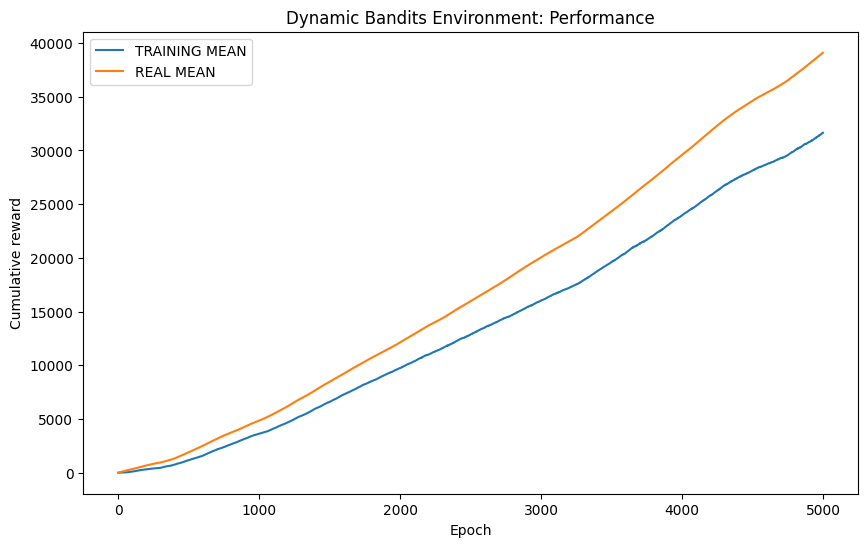

In [258]:
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(training_rewards), label="TRAINING MEAN")
plt.plot(np.cumsum(greedy_q_history), label="REAL MEAN")
plt.title("Dynamic Bandits Environment: Performance")
plt.xlabel("Epoch")
plt.ylabel("Cumulative reward")
plt.legend()
plt.show()